# ============================================================
# BAGIAN 1 — Import Library & Load Data Kaggle
# ============================================================
# Tujuan:
# - Memanggil library yang dibutuhkan.
# - Membaca dataset mobil bekas dari Kaggle (public_cars.csv).
# - Mengecek apakah data berhasil ter-load dengan df.head().

# tampilkan beberapa baris awal untuk memastikan file sudah terbaca
df.head()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ganti path kalau file ada di folder lain
df = pd.read_csv("public_cars.csv")
df.head()

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,price_usd
0,Ford,Fusion,mechanical,blue,245000,2006,gasoline,False,gasoline,1.6,...,False,False,False,False,False,False,False,False,7,4250.0
1,Dodge,Caravan,automatic,silver,265542,2002,gasoline,False,gasoline,3.3,...,False,False,False,False,False,False,False,False,133,4000.0
2,Ford,Galaxy,mechanical,blue,168000,2009,diesel,False,diesel,1.8,...,False,True,False,False,True,True,True,True,0,10900.0
3,Mazda,6,mechanical,other,225522,2008,gasoline,False,gasoline,1.8,...,True,False,False,True,False,False,True,True,20,6999.0
4,Audi,80,mechanical,black,370000,1991,gasoline,False,gasoline,1.8,...,False,False,False,False,False,False,False,True,160,1600.0


# ============================================================
# BAGIAN 2 — Membuat Umur Mobil & Agregasi Harga Rata-rata per Umur
# ============================================================
# Tujuan:
# - Mengubah tahun produksi menjadi variabel umur (age).
# - Membersihkan data yang tidak logis (umur negatif).
# - Menghitung harga rata-rata mobil untuk setiap umur,
#   agar data lebih stabil untuk fitting model penyusutan.

In [2]:
CURRENT_YEAR = 2019
df["age"] = CURRENT_YEAR - df["year_produced"]

# cek apakah ada umur negatif/aneh
df = df[df["age"] >= 0].copy()

# cek hasil setelah pembuatan kolom age
df.head()

# rata-rata harga per umur mobil
age_price = (
    df.groupby("age", as_index=False)["price_usd"]
      .mean()
      .sort_values("age")
)
# tampilkan beberapa nilai rata-rata harga per umur
age_price.head(10)

,age,price_usd
0,0,26967.099677
1,1,19074.462000
2,2,18071.274667
3,3,13677.739000
4,4,17954.857143
5,5,13289.333333
6,6,12605.177400
7,7,12005.903400
8,8,11621.129286
9,9,10714.492000


# ============================================================
# BAGIAN 3 — Visualisasi Data Asli & Estimasi Parameter k dan V0
# ============================================================
# Tujuan:
# - Menampilkan grafik pola penyusutan harga berdasarkan data asli.
# - Membersihkan harga tidak valid (<= 0).
# - Memilih rentang data wajar untuk fitting (umur <= 30).
# - Mengestimasi parameter k dan V0 dengan regresi log-linear:
#     V(t) = V0 * exp(-k t)
#     ln(V) = ln(V0) - k t
#   sehingga slope = -k dan intercept = ln(V0).

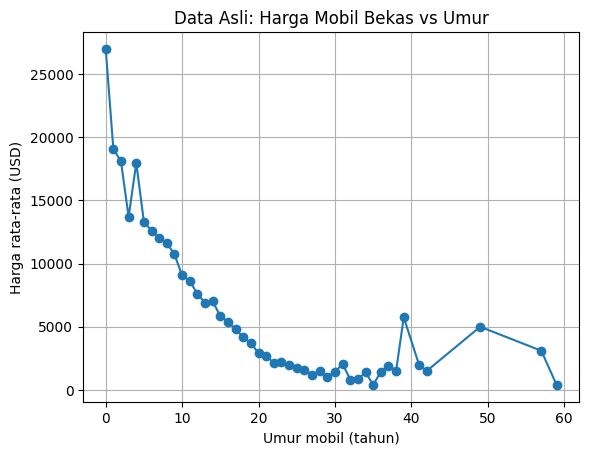

Estimasi k = 0.10292784373479698
Estimasi V0 (regresi) = 24589.62648428203
V0 (data awal) = 26967.099677419355


In [3]:
plt.figure()
plt.plot(age_price["age"], age_price["price_usd"], "o-")
plt.xlabel("Umur mobil (tahun)")
plt.ylabel("Harga rata-rata (USD)")
plt.title("Data Asli: Harga Mobil Bekas vs Umur")
plt.grid(True)
plt.show()

# buang data harga <= 0 karena tidak masuk akal sebagai nilai aset
ap = age_price[age_price["price_usd"] > 0].copy()

# ambil data umur yang "masuk akal" untuk fitting parameter
# batas umur 30 tahun dipilih agar outlier mobil terlalu tua tidak mengganggu regresi
ap_fit = ap[ap["age"] <= 30].copy()

x = ap_fit["age"].values
y = np.log(ap_fit["price_usd"].values)

# regresi linear log(V)=a + b t
b, a = np.polyfit(x, y, 1)

# dari slope dan intercept diperoleh estimasi parameter model
k_est = -b
V0_est = np.exp(a)

print("Estimasi k =", k_est)
print("Estimasi V0 (regresi) =", V0_est)
print("V0 (data awal) =", ap_fit["price_usd"].iloc[0])

# ============================================================
# BAGIAN 4 — Fungsi Euler Forward & Simulasi Baseline
# ============================================================
# Tujuan:
# - Membuat fungsi Euler Forward untuk ODE penyusutan:
#     dV/dt = -kV
#   Euler Forward:
#     V_{n+1} = V_n + h(-kV_n)
# - Menjalankan simulasi awal dengan step size h = 1.0 tahun.

In [4]:
def euler_decay(t0, V0, k, h, duration):
    # hitung jumlah langkah simulasi
    steps = int(duration / h)

    # list untuk menyimpan waktu dan nilai
    ts = [t0]
    Vs = [V0]
    t, V = t0, V0

    for _ in range(steps):
        # update Euler dari dV/dt = -kV
        V = V + h * (-k * V)
        t = t + h
        ts.append(t)
        Vs.append(V)

    return np.array(ts), np.array(Vs)

t0 = ap_fit["age"].min()   # umur awal (biasanya 0)
V0_data = ap_fit["price_usd"].iloc[0]  # harga awal dari data
duration = ap_fit["age"].max() - t0    # lama simulasi sampai umur maksimum

h = 1.0  # baseline step size

# jalankan simulasi Euler baseline
ts, Vs = euler_decay(t0, V0_data, k_est, h, duration)

# cek beberapa nilai awal simulasi
ts[:5], Vs[:5]

(array([0., 1., 2., 3., 4.]),
 array([26967.09967742, 24191.43425584, 21701.46209104, 19467.77739211,
        17464.00104283]))

# ============================================================
# BAGIAN 5 — Hitung MSE & Plot Data vs Simulasi
# ============================================================
# Tujuan:
# - Membandingkan hasil simulasi Euler dengan data asli.
# - Karena titik hasil Euler tidak selalu sama dengan titik umur data,
#   dilakukan interpolasi ke umur data asli.
# - Menghitung error menggunakan Mean Squared Error (MSE).
# - Menampilkan grafik perbandingan data asli vs simulasi.

MSE (h=1.0) = 2739774.6166223874


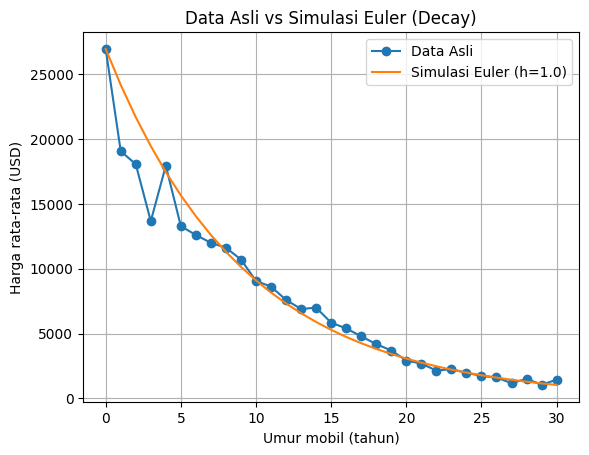

In [5]:
# interpolasi hasil Euler ke titik umur yang ada pada data
pred_at_data = np.interp(ap_fit["age"].values, ts, Vs)

# hitung MSE untuk baseline h=1.0
mse = np.mean((pred_at_data - ap_fit["price_usd"].values) ** 2)
print("MSE (h=1.0) =", mse)

# plot perbandingan data asli vs simulasi Euler
plt.figure()
plt.plot(ap_fit["age"], ap_fit["price_usd"], "o-", label="Data Asli")
plt.plot(ts, Vs, "-", label=f"Simulasi Euler (h={h})")
plt.xlabel("Umur mobil (tahun)")
plt.ylabel("Harga rata-rata (USD)")
plt.title("Data Asli vs Simulasi Euler (Decay)")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# BAGIAN 6 — Uji Beberapa Step Size (h) & Plot Pengaruhnya
# ============================================================
# Tujuan:
# - Menguji beberapa nilai step size h untuk melihat pengaruhnya terhadap error.
# - Semakin kecil h biasanya simulasi lebih halus, tetapi lebih banyak langkah.
# - MSE tiap h dihitung lalu divisualisasikan.

h=0.25  MSE=2976780.1996
h=0.5   MSE=2881045.2458
h=1.0   MSE=2739774.6166
h=2.0   MSE=2779085.7629
h=5.0   MSE=5315592.6199


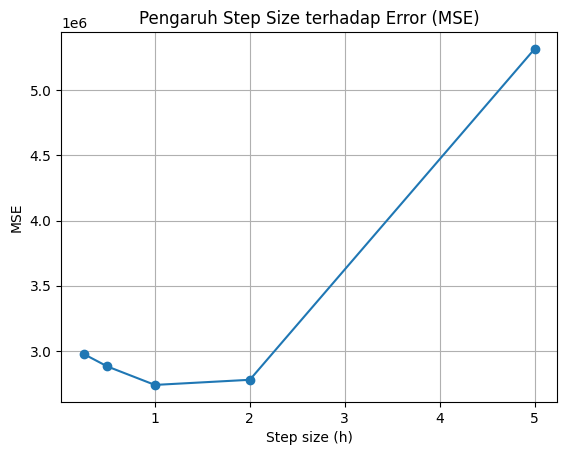

In [6]:
hs = [0.25, 0.5, 1.0, 2.0, 5.0]
mse_list = []

for h_test in hs:
    ts_test, Vs_test = euler_decay(t0, V0_data, k_est, h_test, duration)

    # interpolasi hasil simulasi ke titik umur data asli
    pred_test = np.interp(ap_fit["age"].values, ts_test, Vs_test)

    # hitung MSE untuk tiap h
    mse_test = np.mean((pred_test - ap_fit["price_usd"].values) ** 2)
    mse_list.append(mse_test)

    print(f"h={h_test:<4}  MSE={mse_test:.4f}")

# plot hubungan h vs MSE
plt.figure()
plt.plot(hs, mse_list, "o-")
plt.xlabel("Step size (h)")
plt.ylabel("MSE")
plt.title("Pengaruh Step Size terhadap Error (MSE)")
plt.grid(True)
plt.show()

# ============================================================
# BAGIAN 7 — Menentukan Best h & Hasil Final
# ============================================================
# Tujuan:
# - Memilih step size terbaik berdasarkan MSE terkecil.
# - Menjalankan ulang simulasi dengan best h.
# - Menampilkan grafik hasil final.

Best h = 1.0
Best MSE = 2739774.6166223874


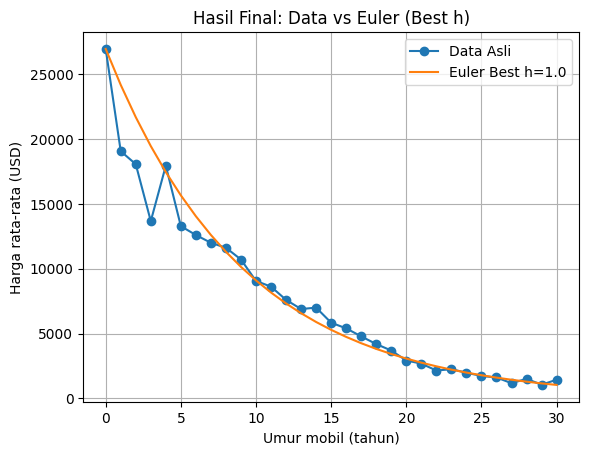

In [7]:
# cari indeks MSE terkecil → best h
best_idx = int(np.argmin(mse_list))
best_h = hs[best_idx]
best_mse = mse_list[best_idx]

print("Best h =", best_h)
print("Best MSE =", best_mse)

# simulasi ulang memakai h terbaik
ts_best, Vs_best = euler_decay(t0, V0_data, k_est, best_h, duration)

# plot hasil final
plt.figure()
plt.plot(ap_fit["age"], ap_fit["price_usd"], "o-", label="Data Asli")
plt.plot(ts_best, Vs_best, "-", label=f"Euler Best h={best_h}")
plt.xlabel("Umur mobil (tahun)")
plt.ylabel("Harga rata-rata (USD)")
plt.title("Hasil Final: Data vs Euler (Best h)")
plt.legend()
plt.grid(True)
plt.show()